In [1]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE
from src.core.models.mil_species_detector import MILSpeciesDetector
from src.core.utils.sketch import make_ax_invisible

plt.rcParams.update({
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlesize': 10, 
})

def wrap_sentence(sentence, max_length):
    words = sentence.split()
    lines = []
    current_line = ""
    for word in words:
        if len(current_line) + len(word) + (1 if current_line else 0) <= max_length:
            if current_line:
                current_line += " " 
            current_line += word
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    return "\n".join(lines)


model_path = pathlib.Path("/its/home/kag25/models/v4")
data = SoundingOutChorus("/its/home/kag25/data/sounding_out")
save_dir = pathlib.Path("/its/home/kag25/experiments/v4/species_interpolations/")
save_dir.mkdir(exist_ok=True, parents=True)

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [10]:
model_class = "vae"
vae_model_name = "lumpy-gibson"
clf_model_name = "live-spoon"
vae = VAE.load_from_checkpoint(model_path / model_class / vae_model_name / "step=180000.ckpt", map_location="cuda").eval()
vae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{vae_model_name}_SO_EC.ckpt", map_location="cuda").eval()
vae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{vae_model_name}_run_id={clf_model_name}.parquet")
vae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Pionus chalcopterus_Bronze-winged Parrot,0.270590,0.905047,18,live-spoon,lumpy-gibson,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.001
1,Todirostrum cinereum_Common Tody-Flycatcher,0.286191,0.875347,22,live-spoon,lumpy-gibson,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.001
2,Trogon rufus_Black-throated Trogon,0.367924,0.894195,22,live-spoon,lumpy-gibson,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.001
3,Megarynchus pitangua_Boat-billed Flycatcher,0.229027,0.908365,23,live-spoon,lumpy-gibson,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.001
4,Manacus manacus_White-bearded Manakin,0.611798,0.946089,43,live-spoon,lumpy-gibson,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.001


In [11]:
model_class = "sivae"
sivae_model_name = "just-drum"
clf_model_name = "robust-nadia"
sivae = SIVAE.load_from_checkpoint(model_path / model_class / sivae_model_name / "step=180000.ckpt", map_location="cuda").eval()
sivae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{sivae_model_name}_SO_EC.ckpt", map_location="cuda").eval()
sivae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{sivae_model_name}_run_id={clf_model_name}.parquet")
sivae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Phaenostictus mcleannani_Ocellated Antbird,0.483108,0.937547,21,robust-nadia,just-drum,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
1,Cantorchilus leucopogon_Stripe-throated Wren,0.202438,0.877925,29,robust-nadia,just-drum,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
2,Odontophorus erythrops_Rufous-fronted Wood-Quail,0.305702,0.924149,28,robust-nadia,just-drum,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
3,Geothlypis semiflava_Olive-crowned Yellowthroat,0.312496,0.903451,14,robust-nadia,just-drum,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
4,Dives warczewiczi_Scrub Blackbird,0.623760,0.879156,57,robust-nadia,just-drum,SO_EC,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005


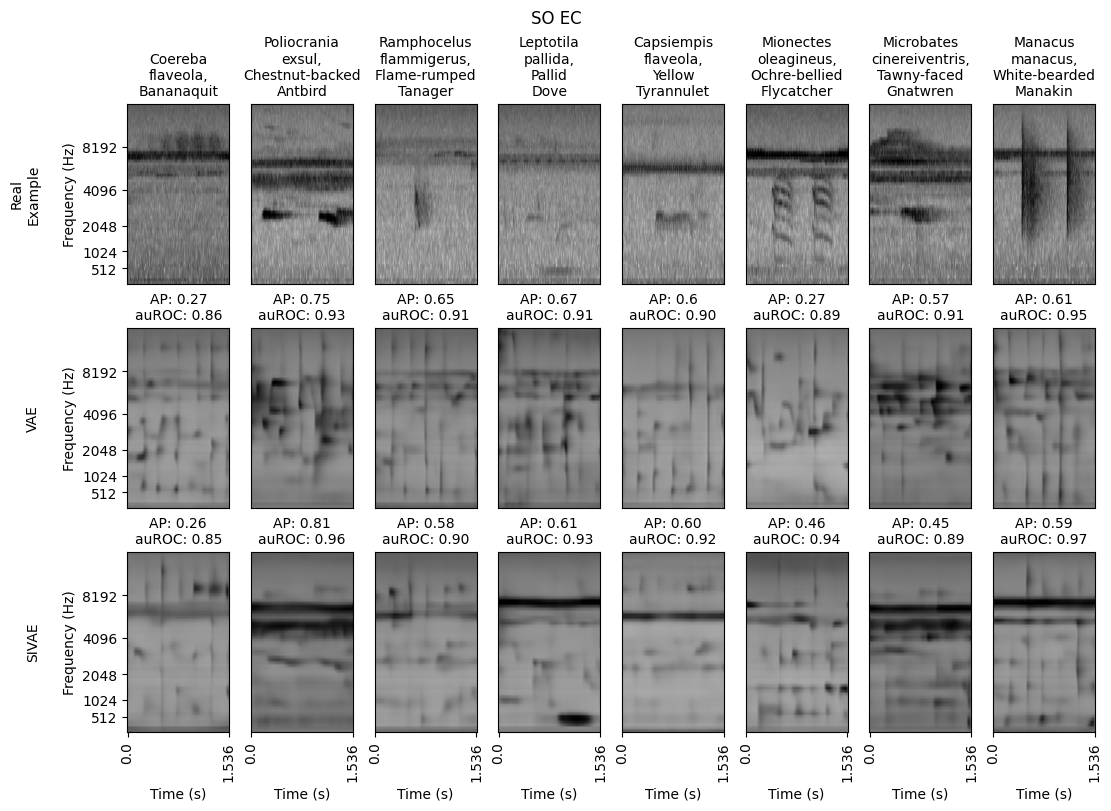

In [25]:
species_params = [ 
    { "species_name": "Coereba flaveola_Bananaquit", "file_name": "train/data/FS-11_0_20150806_0600.wav", "t_start_seconds": 32.4 },
    { "species_name": "Poliocrania exsul_Chestnut-backed Antbird", "file_name": "train/data/TE-03_0_20150716_0635.wav", "t_start_seconds": 25.2 },
    { "species_name": "Ramphocelus flammigerus_Flame-rumped Tanager", "file_name": "test/data/PO-11_0_20150815_1815.wav", "t_start_seconds": 0.0 },
    { "species_name": "Leptotila pallida_Pallid Dove", "file_name": "train/data/PO-11_0_20150818_0625.wav", "t_start_seconds": 6.5 },
    { "species_name": "Capsiempis flaveola_Yellow Tyrannulet", "file_name": "train/data/PO-03_0_20150815_0640.wav", "t_start_seconds": 16.0 },
    { "species_name": "Mionectes oleagineus_Ochre-bellied Flycatcher", "file_name": "train/data/FS-16_0_20150802_0645.wav", "t_start_seconds": 0.2 },
    { "species_name": "Microbates cinereiventris_Tawny-faced Gnatwren", "file_name": "train/data/TE-06_0_20150716_0645.wav", "t_start_seconds": 33.5 },
    { "species_name": "Manacus manacus_White-bearded Manakin", "file_name": "train/data/FS-04_0_20150802_0650.wav", "t_start_seconds": 41.2},
]   
for params in species_params:
    counts = data.metadata.merge(
        data.labels.astype(bool).astype(int),
        left_index=True,
        right_index=True
    ).groupby("habitat")[params["species_name"]].sum().reset_index()
    params["habitat"] = counts.loc[counts[params["species_name"]].idxmax()].habitat

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(species_params) + 1,
    figsize=(11, 8),
    width_ratios=[0.01, *[0.95 / (len(species_params)) for _ in range(len(species_params))]],
    constrained_layout=True,
)
vmax, vmin = 0.0, -80
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

model_habitat_means = {}
for j, (model_name, vae, clf) in enumerate([(vae_model_name, vae, vae_clf), (sivae_model_name, sivae, sivae_clf)]):
    dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/SO_EC").setup()
    embeddings = dm.train_data
    features = embeddings.features
    labels = embeddings.labels.reset_index()
    labels = labels.merge(data.metadata.loc[data.metadata.index.isin(labels.file_i), ["file_name", "habitat"]], on='file_i', how="inner")
    # encode the habitat mean representation for this model
    z_mean = embeddings.features[[f"z_mean_{i}" for i in range(128)]].merge(labels[["file_i", "habitat"]], on="file_i", how="left").drop("file_i", axis=1).groupby("habitat").mean()
    habitat_means = {
        habitat: torch.tensor(z_mean.loc[habitat], dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0)
        for habitat in z_mean.index
    }
    model_habitat_means[j] = habitat_means

model_params = {
    "vae": {
        "Coereba flaveola_Bananaquit": {"delta": 25, "shift": 0.0},
        "Poliocrania exsul_Chestnut-backed Antbird": {"delta": 10, "shift": 0.0},
        "Ramphocelus flammigerus_Flame-rumped Tanager": {"delta": 15, "shift": 0.0},
        "Leptotila pallida_Pallid Dove": {"delta": 15, "shift": 0.0},
        "Capsiempis flaveola_Yellow Tyrannulet": {"delta": 25, "shift": 0.0},
        "Mionectes oleagineus_Ochre-bellied Flycatcher": {"delta": 30, "shift": 0.0},
        "Microbates cinereiventris_Tawny-faced Gnatwren": {"delta": 15, "shift": 0.0},
        "Manacus manacus_White-bearded Manakin": {"delta": 20, "shift": 0.0},
    },
    "sivae": {
        "Coereba flaveola_Bananaquit": {"delta": 25, "shift": 0.0},
        "Poliocrania exsul_Chestnut-backed Antbird": {"delta": 10, "shift": 0.0},
        "Ramphocelus flammigerus_Flame-rumped Tanager": {"delta": 15, "shift": 0.0},
        "Leptotila pallida_Pallid Dove": {"delta": 15, "shift": 0.0},
        "Capsiempis flaveola_Yellow Tyrannulet": {"delta": 25, "shift": 0.0},
        "Mionectes oleagineus_Ochre-bellied Flycatcher": {"delta": 30, "shift": 0.0},
        "Microbates cinereiventris_Tawny-faced Gnatwren": {"delta": 15, "shift": 0.0},
        "Manacus manacus_White-bearded Manakin": {"delta": 30, "shift": 0.0},
    },
}
with torch.no_grad():
    for i, params in enumerate(species_params):
        species_name, file_name, t_start_seconds, habitat = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("VAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[2, 0]
            title_ax.set_ylabel("SIVAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        ax.set_title(wrap_sentence(species_name.replace("_", ", "), 10))
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        
        for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
            delta, shift = model_params[model_class][species_name].values()
            ap, auroc = scores[scores.species_name == species_name][["AP", "auROC"]].iloc[0].to_dict().values()
            z = model_habitat_means[j][habitat]
            W = clf.species_weights(species_name)
            norm = torch.linalg.norm(W)
            z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
            x_tilde_db = 20 * np.log10(x_tilde.exp())
            ax = axes[j + 1, i + 1]
            vae.front_end.plot(x_tilde_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax)
            ax.tick_params(labelbottom=False, bottom=False)
            ax.set_xlabel("")
            ax.set_title(f"AP: {np.format_float_positional(ap, precision=2)}\nauROC: {np.format_float_positional(auroc, precision=2)}")
            
for ax in axes[:, 2:].flatten():
    ax.set_ylabel("")
    ax.tick_params(labelleft=False, left=False)

for ax in axes[-1, 1:].flatten():
    ax.tick_params(labelbottom=True, bottom=True)
    ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
    ax.set_xlabel("Time (s)")

fig.suptitle("SO EC")
fig.savefig(save_dir / "so_ec_interpolation.pdf", format="pdf")
plt.show()